✅ داده بارگذاری شد: 12784 روز
✅ نمودار ذخیره شد: streamflow_plot.png


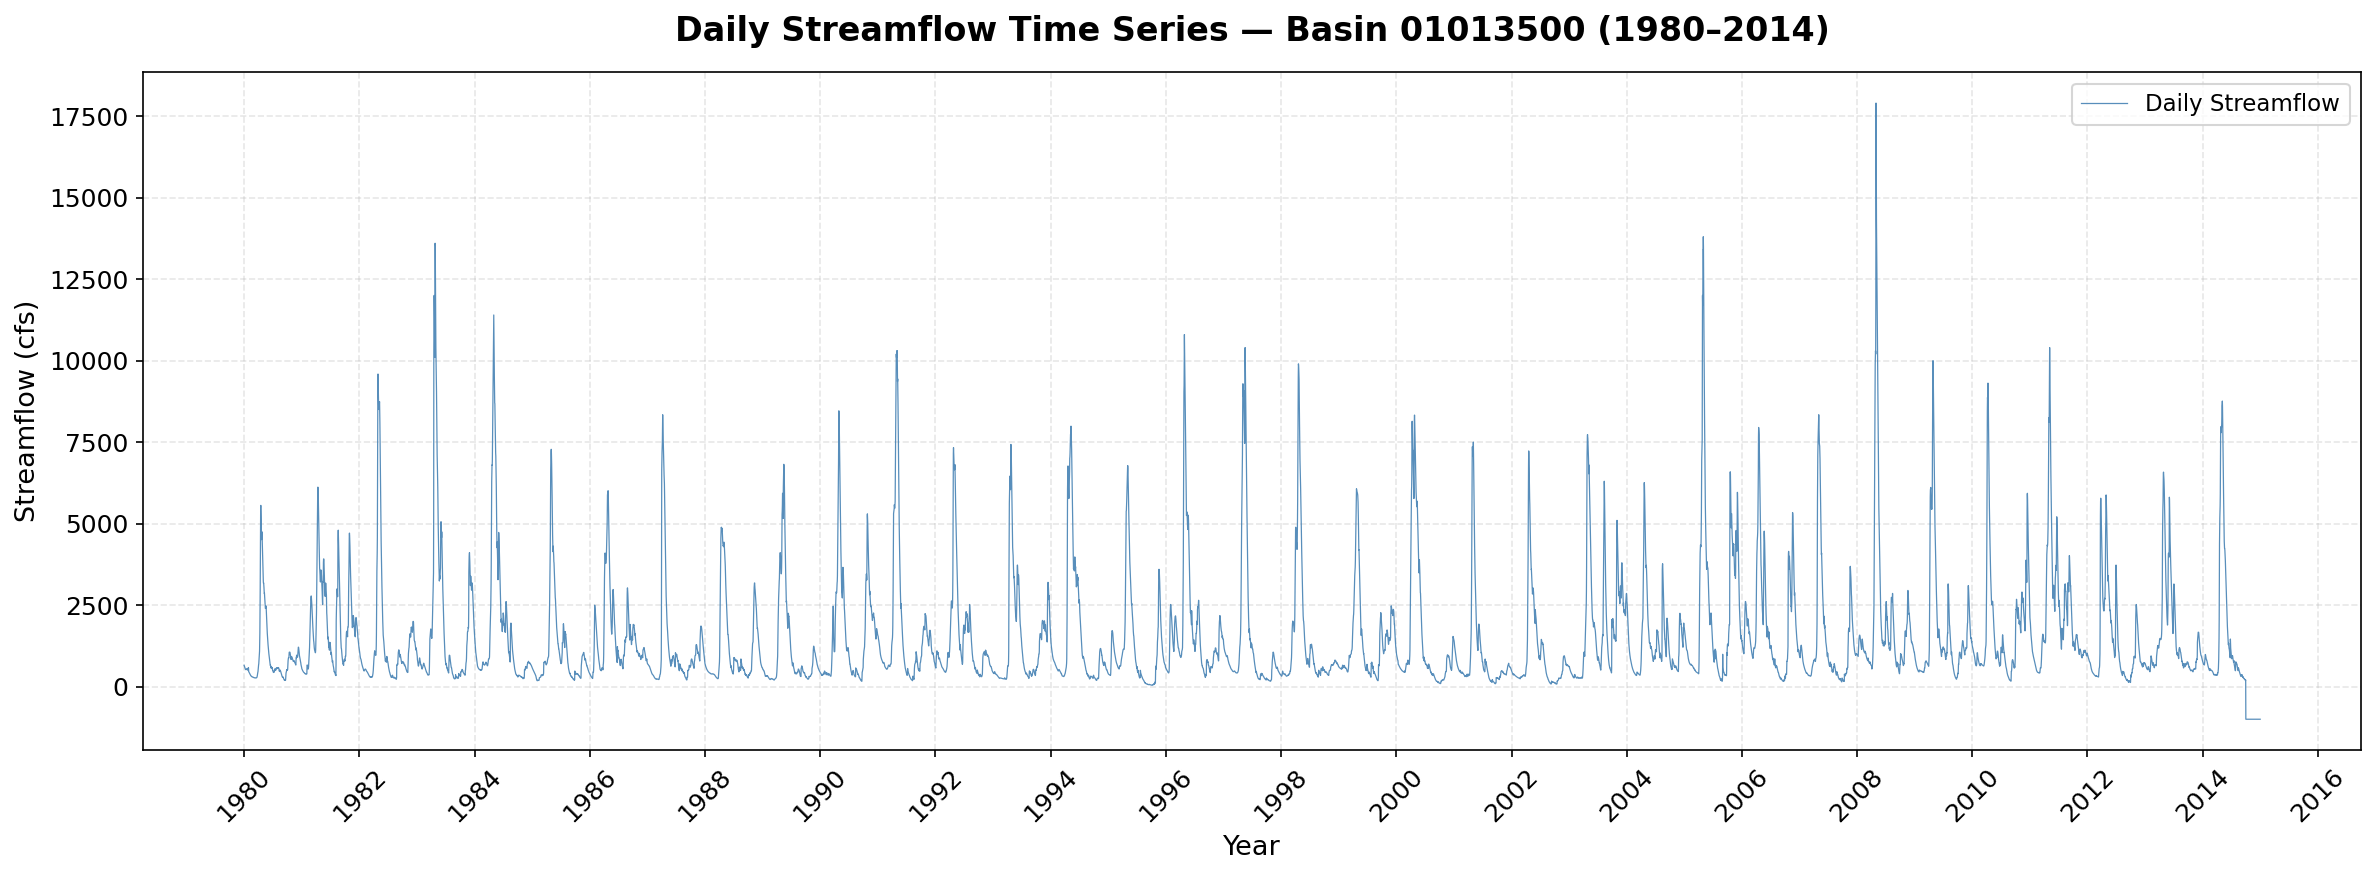

🎉 روز ۵ تموم شد!


In [1]:
# ============================================
# روز ۵ تیر - قشنگ‌سازی نمودار دبی
# پروژه: CAMELS - حوضه 01013500
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ---------- ۱. بارگذاری داده (از فایل تمیز دیروز) ----------
df = pd.read_csv("clean_streamflow.txt", sep=r"\s+", header=None,
                 names=["basin", "year", "month", "day", "streamflow", "flag"])

df["streamflow"] = pd.to_numeric(df["streamflow"], errors="coerce")
df = df.dropna()
df["date"] = pd.to_datetime(df[["year", "month", "day"]])
df = df.set_index("date")
df = df.sort_index()

print(f"✅ داده بارگذاری شد: {len(df)} روز")

# ---------- ۲. تنظیمات ظاهری ----------
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 150

# ---------- ۳. رسم نمودار حرفه‌ای ----------
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(df.index, df["streamflow"],
        color="steelblue",
        linewidth=0.6,
        alpha=0.9,
        label="Daily Streamflow")

# عنوان‌ها
ax.set_title("Daily Streamflow Time Series — Basin 01013500 (1980–2014)",
             fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("Streamflow (cfs)", fontsize=13)

# محور X شمرده
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)

# شبکه و راهنما
ax.grid(True, alpha=0.3, linestyle="--")
ax.legend(loc="upper right", fontsize=11)

plt.tight_layout()

# ---------- ۴. ذخیره عکس ----------
plt.savefig("streamflow_plot.png", dpi=300, bbox_inches="tight")
print("✅ نمودار ذخیره شد: streamflow_plot.png")

plt.show()
print("🎉 روز ۵ تموم شد!")